In [ ]:
from urllib.request import urlopen

html = urlopen("http://example.com/")

html.read()

b'<!doctype html><html lang="en"><head><title>Example Domain</title><meta name="viewport" content="width=device-width, initial-scale=1"><style>body{background:#eee;width:60vw;margin:15vh auto;font-family:system-ui,sans-serif}h1{font-size:1.5em}div{opacity:0.8}a:link,a:visited{color:#348}</style></head><body><div><h1>Example Domain</h1><p>This domain is for use in documentation examples without needing permission. Avoid use in operations.</p><p><a href="https://iana.org/domains/example">Learn more</a></p></div></body></html>\n'

In [ ]:
from urllib.request import urlopen
from bs4 import BeautifulSoup

html = urlopen("http://example.com/")
bs = BeautifulSoup(html.read())


print(bs.title)

for link in bs.find_all("a", href=True):
    print('link:', link["href"])

<title>Example Domain</title>
link: https://iana.org/domains/example


In [ ]:
import pandas as pd
from bs4 import BeautifulSoup

html = """
<div class="produto">
    <h2>Notebook</h2>
    <span class="preco">3500</span>
</div>

<div class="produto">
    <h2>Mouse</h2>
    <span class="preco">80</span>
</div>

<div class="produto">
    <h2>Teclado</h2>
    <span class="preco">150</span>
</div>
"""

soup = BeautifulSoup(html, 'html.parser')

products_data = []
for product_div in soup.find_all('div', class_='produto'):
    product_name = product_div.find('h2').get_text(strip=True)
    product_price = product_div.find('span', class_='preco').get_text(strip=True)
    products_data.append({'Produto': product_name, 'Preço': product_price})

df = pd.DataFrame(products_data)
display(df)

,Produto,Preço
0,Notebook,3500
1,Mouse,80
2,Teclado,150


In [ ]:
from bs4 import BeautifulSoup

# Assuming 'bs' object is available from the previous execution

css_selector = "#mvp-content-main > h2:nth-child(19) > strong"

selected_element = bs.select_one(css_selector)

if selected_element:
    print(f"Text from selected element: {selected_element.get_text(strip=True)}")
else:
    print(f"No element found with the CSS selector: {css_selector}")

Text from selected element: 2. Acessórios para celular


In [ ]:
import pandas as pd

# Ensure numbered_categories_df is available, if not, re-create it (it should be from previous step)
if 'df_product_categories' in locals() and 'numbered_categories_df' not in locals():
    numbered_categories_df = df_product_categories[df_product_categories['Categorias de Produtos'].str.match(r'^\\d+\\.', na=False)]

# Sort the DataFrame based on the numerical part of the 'Categorias de Produtos' column
# Extract the number, convert to integer, and use it as a sorting key
sorted_numbered_categories_df = numbered_categories_df.copy()
sorted_numbered_categories_df['Sort Key'] = sorted_numbered_categories_df['Categorias de Produtos'].apply(lambda x: int(x.split('.')[0]))
sorted_numbered_categories_df = sorted_numbered_categories_df.sort_values(by='Sort Key').drop(columns='Sort Key').reset_index(drop=True)

display(sorted_numbered_categories_df)

,Categorias de Produtos
0,1. Smartphones e celulares
1,2. Acessórios para celular
2,3. Eletrodomésticos
3,4. Informática e tecnologia
4,5. TVs e eletrônicos
5,"6. Casa, móveis e decoração"
6,7. Moda e acessórios
7,8. Beleza e cuidados pessoais
8,9. Saúde e bem-estar
9,10. Automotivo


In [ ]:
import requests
from bs4 import BeautifulSoup

url = "https://en.wikipedia.org/wiki/Artificial_intelligence"

response = requests.get(url)

soup = BeautifulSoup(response.text, "html.parser")

links = soup.find_all("a")

for a in links[:5]:
	print(a)

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

base_url = "https://quotes.toscrape.com/"
all_quotes_data = []
page_number = 1

while True:
    url = f"{base_url}page/{page_number}/"
    print(f"Scraping page: {url}")

    try:
        response = requests.get(url)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
        soup = BeautifulSoup(response.text, 'html.parser')

        # Each quote is contained within a div with class 'quote'
        quotes_on_page = soup.find_all('div', class_='quote')

        if not quotes_on_page: # No more quotes found, means end of pages
            break

        for quote_div in quotes_on_page:
            quote_text = quote_div.find('span', class_='text')
            author_name = quote_div.find('small', class_='author')

            if quote_text and author_name:
                all_quotes_data.append({
                    'Quote': quote_text.get_text(strip=True),
                    'Author': author_name.get_text(strip=True)
                })

        # Check for a 'next' button
        next_button = soup.find('li', class_='next')
        if not next_button:
            break # No 'next' button, so this is the last page

        page_number += 1

    except requests.exceptions.RequestException as e:
        print(f"Error fetching URL {url}: {e}")
        break
    except Exception as e:
        print(f"An error occurred on page {url}: {e}")
        break

df_all_quotes = pd.DataFrame(all_quotes_data)
display(df_all_quotes)

Scraping page: https://quotes.toscrape.com/page/1/
Scraping page: https://quotes.toscrape.com/page/2/
Scraping page: https://quotes.toscrape.com/page/3/
Scraping page: https://quotes.toscrape.com/page/4/
Scraping page: https://quotes.toscrape.com/page/5/
Scraping page: https://quotes.toscrape.com/page/6/
Scraping page: https://quotes.toscrape.com/page/7/
Scraping page: https://quotes.toscrape.com/page/8/
Scraping page: https://quotes.toscrape.com/page/9/
Scraping page: https://quotes.toscrape.com/page/10/


,Quote,Author
0,“The world as we have created it is a process ...,Albert Einstein
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling
2,“There are only two ways to live your life. On...,Albert Einstein
3,"“The person, be it gentleman or lady, who has ...",Jane Austen
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe
...,...,...
95,“You never really understand a person until yo...,Harper Lee
96,“You have to write the book that wants to be w...,Madeleine L'Engle
97,“Never tell the truth to people who are not wo...,Mark Twain
98,"“A person's a person, no matter how small.”",Dr. Seuss


In [ ]:
# Convert the DataFrame to CSV string
csv_output = df_all_quotes.to_csv(index=False)

# Display the CSV output
print(csv_output)

# If you want to save it to a file in Colab, you can use:
with open('quotes.csv', 'w', encoding='utf-8') as f:
    f.write(csv_output)
print("Data saved to quotes.csv")

Quote,Author
“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”,Albert Einstein
"“It is our choices, Harry, that show what we truly are, far more than our abilities.”",J.K. Rowling
“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”,Albert Einstein
"“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”",Jane Austen
"“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”",Marilyn Monroe
“Try not to become a man of success. Rather become a man of value.”,Albert Einstein
“It is better to be hated for what you are than to be loved for what you are not.”,André Gide
"“I have not failed. I've just found 10,000 ways that won't work.”",Thomas A. Edison
“A woman is like a tea bag; you never know how strong it is until it's in hot water.”,Eleanor R

In [ ]:
!pip install wordcloud matplotlib

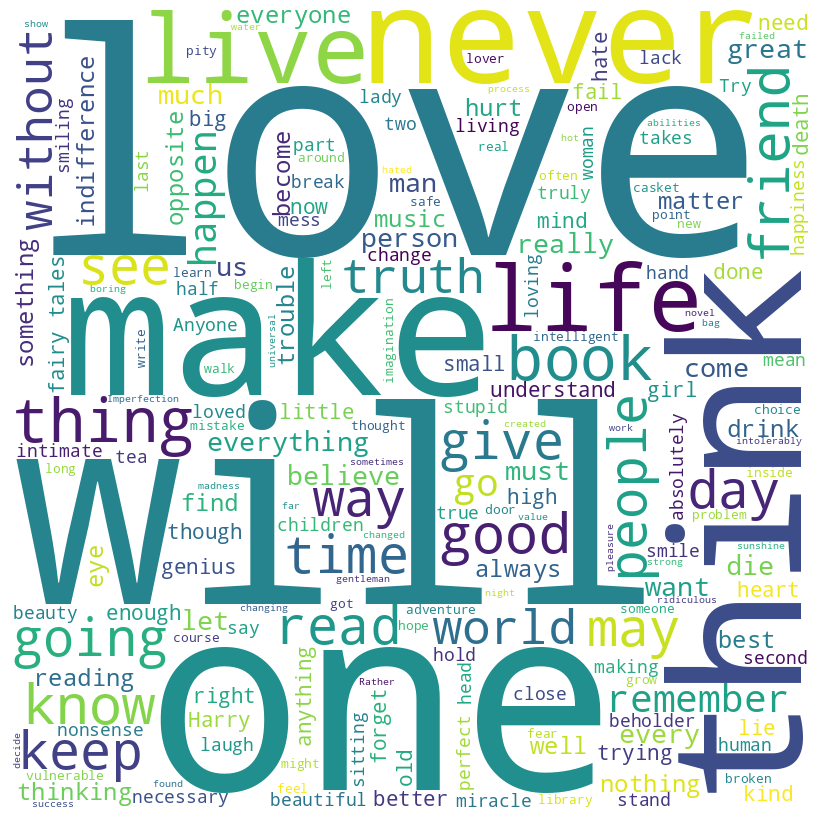

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all quotes into a single string
# Ensure df_all_quotes is available from previous steps
if 'df_all_quotes' in locals():
    all_quotes_text = ' '.join(df_all_quotes['Quote'].astype(str))

    # Generate a word cloud image
    wordcloud = WordCloud(width = 800, height = 800,
                        background_color ='white',
                        min_font_size = 10).generate(all_quotes_text)

    # Display the generated image:
    plt.figure(figsize = (8, 8), facecolor = None)
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.tight_layout(pad = 0)
    plt.show()
else:
    print("Error: df_all_quotes DataFrame not found. Please ensure the previous scraping step was executed.")

In [ ]:
# Convert the DataFrame of books to CSV string
csv_books_output = df_books.to_csv(index=False)

# Display the CSV output
print(csv_books_output)

# If you want to save it to a file in Colab, you can use:
with open('books.csv', 'w', encoding='utf-8') as f:
    f.write(csv_books_output)
print("Data saved to books.csv")

Title,Category,Rating,Price
A Light in the Attic,All products,Three,Â£51.77
Tipping the Velvet,All products,One,Â£53.74
Soumission,All products,One,Â£50.10
Sharp Objects,All products,Four,Â£47.82
Sapiens: A Brief History of Humankind,All products,Five,Â£54.23
The Requiem Red,All products,One,Â£22.65
The Dirty Little Secrets of Getting Your Dream Job,All products,Four,Â£33.34
"The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull",All products,Three,Â£17.93
The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics,All products,Four,Â£22.60
The Black Maria,All products,One,Â£52.15
"Starving Hearts (Triangular Trade Trilogy, #1)",All products,Two,Â£13.99
Shakespeare's Sonnets,All products,Four,Â£20.66
Set Me Free,All products,Five,Â£17.46
Scott Pilgrim's Precious Little Life (Scott Pilgrim #1),All products,Five,Â£52.29
Rip it Up and Start Again,All products,Five,Â£35.02
"Our Band Could Be Your Life: Scenes from the Ame

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

base_url = "https://books.toscrape.com/"
all_books_data = []
page_number = 1

while True:
    # Construct URL for the current page
    if page_number == 1:
        url = f"{base_url}index.html"
    else:
        url = f"{base_url}catalogue/page-{page_number}.html"

    print(f"Scraping page: {url}")

    try:
        response = requests.get(url)
        response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)
        soup = BeautifulSoup(response.text, 'html.parser')

        # Check if there are any books on this page
        books_on_page = soup.find_all('article', class_='product_pod')

        if not books_on_page:
            # No more books found, means end of pages
            break

        # Extract the general category for the current page (from breadcrumbs)
        # For the main catalogue pages, this will typically be 'Books'.
        # For category-specific pages, it would be that category name.
        page_category_element = soup.find('ul', class_='breadcrumb')
        page_category = 'N/A'
        if page_category_element:
            # The last li in breadcrumb is the current page's category
            active_breadcrumb = page_category_element.find_all('li')
            if len(active_breadcrumb) > 1: # Ensure there's a category beyond 'Home'
                page_category = active_breadcrumb[-1].get_text(strip=True)
            else:
                page_category = 'Books'


        for book in books_on_page:
            title = book.h3.a['title']
            price = book.find('p', class_='price_color').get_text(strip=True)
            rating = book.find('p', class_='star-rating')['class'][1] # e.g., 'Three', 'Four'

            all_books_data.append({
                'Title': title,
                'Category': page_category, # This will be 'Books' for the main catalogue
                'Rating': rating,
                'Price': price
            })

        # Check for a 'next' button to determine if there are more pages
        next_button = soup.find('li', class_='next')
        if not next_button:
            break  # No 'next' button, so this is the last page

        page_number += 1

    except requests.exceptions.RequestException as e:
        print(f"Error fetching URL {url}: {e}")
        break
    except Exception as e:
        print(f"An error occurred on page {url}: {e}")
        break

df_books = pd.DataFrame(all_books_data)
display(df_books.head())
print(f"Total books scraped: {len(df_books)}")

Scraping page: https://books.toscrape.com/index.html
Scraping page: https://books.toscrape.com/catalogue/page-2.html
Scraping page: https://books.toscrape.com/catalogue/page-3.html
Scraping page: https://books.toscrape.com/catalogue/page-4.html
Scraping page: https://books.toscrape.com/catalogue/page-5.html
Scraping page: https://books.toscrape.com/catalogue/page-6.html
Scraping page: https://books.toscrape.com/catalogue/page-7.html
Scraping page: https://books.toscrape.com/catalogue/page-8.html
Scraping page: https://books.toscrape.com/catalogue/page-9.html
Scraping page: https://books.toscrape.com/catalogue/page-10.html
Scraping page: https://books.toscrape.com/catalogue/page-11.html
Scraping page: https://books.toscrape.com/catalogue/page-12.html
Scraping page: https://books.toscrape.com/catalogue/page-13.html
Scraping page: https://books.toscrape.com/catalogue/page-14.html
Scraping page: https://books.toscrape.com/catalogue/page-15.html
Scraping page: https://books.toscrape.com/cat

,Title,Category,Rating,Price
0,A Light in the Attic,All products,Three,Â£51.77
1,Tipping the Velvet,All products,One,Â£53.74
2,Soumission,All products,One,Â£50.10
3,Sharp Objects,All products,Four,Â£47.82
4,Sapiens: A Brief History of Humankind,All products,Five,Â£54.23


Total books scraped: 1000


In [ ]:
# Convert the DataFrame of books to CSV string and save to 'books.csv'
csv_books_output = df_books.to_csv(index=False)

with open('books.csv', 'w', encoding='utf-8') as f:
    f.write(csv_books_output)
print("Data saved to books.csv with corrected categories.")

Data saved to books.csv with corrected categories.


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

base_url = "https://books.toscrape.com/"
all_books_data = []

def get_categories(soup):
    categories = {}
    sidebar_categories = soup.find('div', class_='side_categories')
    if sidebar_categories:
        for li in sidebar_categories.find_all('li'):
            link = li.find('a')
            if link and link.get_text(strip=True) != 'Books': # Skip the top-level 'Books' category
                category_name = link.get_text(strip=True)
                category_url_suffix = link['href']
                # Construct full URL for the category, ensuring correct path
                full_category_url = requests.compat.urljoin(base_url, category_url_suffix)
                categories[category_name] = full_category_url
    return categories

# Step 1: Get all categories
print("Fetching categories...")
response = requests.get(base_url)
response.raise_for_status()
soup = BeautifulSoup(response.text, 'html.parser')
categories_to_scrape = get_categories(soup)
print(f"Found {len(categories_to_scrape)} categories: {', '.join(categories_to_scrape.keys())}")

# Step 2: Iterate through each category and its pages
for category_name, category_base_url in categories_to_scrape.items():
    print(f"\nScraping category: {category_name}")
    page_number = 1

    while True:
        # Construct URL for the current page within the category
        if page_number == 1:
            # For the first page, the URL is the base category URL (e.g., .../travel_2/index.html)
            url = category_base_url
        else:
            # For subsequent pages, the URL pattern is .../travel_2/page-N.html
            # We need to adjust the category_base_url to handle the 'index.html' part
            parts = category_base_url.split('/')
            # Assuming the last part is 'index.html', we replace it with 'page-N.html'
            if parts[-1] == 'index.html':
                parts[-1] = f'page-{page_number}.html'
                url = '/'.join(parts)
            else:
                # Fallback if category_base_url doesn't end with index.html directly
                # This case might need adjustment based on exact URL structure if different.
                url = f"{category_base_url.rstrip('/')}/page-{page_number}.html"

        print(f"  Scraping page {page_number} for {category_name}: {url}")

        try:
            response = requests.get(url)
            response.raise_for_status()
            soup = BeautifulSoup(response.text, 'html.parser')

            books_on_page = soup.find_all('article', class_='product_pod')

            if not books_on_page:
                break # No more books on this category page

            for book in books_on_page:
                title = book.h3.a['title']
                price = book.find('p', class_='price_color').get_text(strip=True)
                rating = book.find('p', class_='star-rating')['class'][1] # e.g., 'Three', 'Four'

                all_books_data.append({
                    'Title': title,
                    'Category': category_name, # Use the specific category name
                    'Rating': rating,
                    'Price': price
                })

            # Check for a 'next' button within the category page
            next_button = soup.find('li', class_='next')
            if not next_button:
                break # No 'next' button, so this is the last page for this category

            page_number += 1

        except requests.exceptions.RequestException as e:
            print(f"  Error fetching URL {url}: {e}")
            break
        except Exception as e:
            print(f"  An error occurred on page {url} for category {category_name}: {e}")
            break

df_books = pd.DataFrame(all_books_data)
display(df_books.head())
print(f"Total books scraped: {len(df_books)}")

Fetching categories...
Found 50 categories: Travel, Mystery, Historical Fiction, Sequential Art, Classics, Philosophy, Romance, Womens Fiction, Fiction, Childrens, Religion, Nonfiction, Music, Default, Science Fiction, Sports and Games, Add a comment, Fantasy, New Adult, Young Adult, Science, Poetry, Paranormal, Art, Psychology, Autobiography, Parenting, Adult Fiction, Humor, Horror, History, Food and Drink, Christian Fiction, Business, Biography, Thriller, Contemporary, Spirituality, Academic, Self Help, Historical, Christian, Suspense, Short Stories, Novels, Health, Politics, Cultural, Erotica, Crime

Scraping category: Travel
  Scraping page 1 for Travel: https://books.toscrape.com/catalogue/category/books/travel_2/index.html

Scraping category: Mystery
  Scraping page 1 for Mystery: https://books.toscrape.com/catalogue/category/books/mystery_3/index.html
  Scraping page 2 for Mystery: https://books.toscrape.com/catalogue/category/books/mystery_3/page-2.html

Scraping category: Hist

,Title,Category,Rating,Price
0,It's Only the Himalayas,Travel,Two,Â£45.17
1,Full Moon over Noahâs Ark: An Odyssey to Mou...,Travel,Four,Â£49.43
2,See America: A Celebration of Our National Par...,Travel,Three,Â£48.87
3,Vagabonding: An Uncommon Guide to the Art of L...,Travel,Two,Â£36.94
4,Under the Tuscan Sun,Travel,Three,Â£37.33


Total books scraped: 1000


In [ ]:
import requests
from bs4 import BeautifulSoup

pet_shop_url = "https://www.araujo.com.br/pet-shop"

print(f"Fetching HTML from: {pet_shop_url}")

try:
    response = requests.get(pet_shop_url)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
    soup_pet_shop = BeautifulSoup(response.text, 'html.parser')

    # Print a portion of the HTML to inspect its structure
    print(soup_pet_shop.prettify()[:2000])
    print("\n--- End of HTML preview ---")
    print("Please examine the HTML above to find the correct CSS selectors for product names and prices.")

except requests.exceptions.RequestException as e:
    print(f"Error fetching URL {pet_shop_url}: {e}")
except Exception as e:
    print(f"An error occurred: {e}")

Fetching HTML from: https://www.araujo.com.br/pet-shop
<!DOCTYPE html>
<html lang="pt-BR">
 <head>
  <meta charset="utf-8"/>
  <meta content="ie=edge" http-equiv="x-ua-compatible"/>
  <title>
   Pet Shop - Araujo
  </title>
  <meta content="Compre itens de Pet Shop na Drogaria Araujo. Tudo para o bem-estar do seu animalzinho. Entrega para todo o Brasil." name="description">
   <meta content="Drogaria Araujo" name="keywords">
    <meta content="width=device-width, initial-scale=1, maximum-scale=5" name="viewport"/>
    <meta content="index,follow" name="robots"/>
    <meta content="index, follow" name="googlebot"/>
    <meta content="script-src 'self' 'unsafe-inline' 'unsafe-eval' https://tagmanager.google.com https://www.googletagmanager.com https://www.google.com/recaptcha/api.js *.jquery.com *.cloudflare.com *.cquotient.com *.jsdelivr.net *.googleapis.com https://cdn-prod.securiti.ai https://trustvox.com.br https://rate.trustvox.com.br https://static.trustvox.com.br *.clearsale.com.b

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

base_url = "https://www.araujo.com.br/pet-shop"
all_pet_products_data = []
current_page_url = base_url
page_counter = 1

while True:
    print(f"Scraping page {page_counter} from: {current_page_url}")

    try:
        response = requests.get(current_page_url)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
        soup_pet_shop = BeautifulSoup(response.text, 'html.parser')

        products = soup_pet_shop.find_all('div', class_='productTile')

        if products:
            for product in products:
                product_name = product.get('title', 'N/A')
                price_element = product.find('span', class_='productPrice__price')
                product_price = price_element.get_text(strip=True) if price_element else 'N/A'
                all_pet_products_data.append({'Produto': product_name, 'Preço': product_price})
        else:
            print(f"No products found on page {page_counter}. Stopping pagination.")
            break

        # Find the next page link
        # The pagination links seem to be within a div.productGrid__footer > ul
        # Looking for a 'next' button or 'next-page' class
        next_page_link = None
        pagination_footer = soup_pet_shop.find('div', class_='productGrid__footer')
        if pagination_footer:
            # Look for an <a> tag within an <li> that has 'next' in its class or text
            # Example: <li class="next-page"><a href="..." title="Próxima Página">...</a></li>
            next_button = pagination_footer.find('li', class_='next-page')
            if next_button:
                next_page_link = next_button.find('a')
            # If 'next-page' class is not found, look for an <a> with text containing 'next'
            if not next_page_link:
                 for link in pagination_footer.find_all('a'):
                     if 'próxima' in link.get_text(strip=True).lower(): # Assuming Portuguese for 'next'
                         next_page_link = link
                         break

        if next_page_link and next_page_link.get('href'):
            current_page_url = requests.compat.urljoin(base_url, next_page_link['href'])
            page_counter += 1
        else:
            print(f"No next page link found on page {page_counter}. Finishing scraping.")
            break # No next page link, so this is the last page

    except requests.exceptions.RequestException as e:
        print(f"Error fetching URL {current_page_url}: {e}")
        break
    except Exception as e:
        print(f"An error occurred on page {current_page_url}: {e}")
        break

# Create DataFrame from all collected data
df_araujo_pet_shop = pd.DataFrame(all_pet_products_data)

# Display head of the DataFrame and total count
display(df_araujo_pet_shop.head())
print(f"Total pet products scraped: {len(df_araujo_pet_shop)}")

# Save to CSV
csv_output_araujo = df_araujo_pet_shop.to_csv(index=False)
with open('araujo.csv', 'w', encoding='utf-8') as f:
    f.write(csv_output_araujo)
print("Data saved to araujo.csv")

Scraping page 1 from: https://www.araujo.com.br/pet-shop
Scraping page 2 from: https://www.araujo.com.br/busca?cgid=6&start=48&sz=48&page=2
Scraping page 3 from: https://www.araujo.com.br/busca?cgid=6&start=96&sz=48&page=3
Scraping page 4 from: https://www.araujo.com.br/busca?cgid=6&start=144&sz=48&page=4
Scraping page 5 from: https://www.araujo.com.br/busca?cgid=6&start=192&sz=48&page=5
Scraping page 6 from: https://www.araujo.com.br/busca?cgid=6&start=240&sz=48&page=6
Scraping page 7 from: https://www.araujo.com.br/busca?cgid=6&start=288&sz=48&page=7
Scraping page 8 from: https://www.araujo.com.br/busca?cgid=6&start=336&sz=48&page=8
Scraping page 9 from: https://www.araujo.com.br/busca?cgid=6&start=384&sz=48&page=9
Scraping page 10 from: https://www.araujo.com.br/busca?cgid=6&start=432&sz=48&page=10
Scraping page 11 from: https://www.araujo.com.br/busca?cgid=6&start=480&sz=48&page=11
Scraping page 12 from: https://www.araujo.com.br/busca?cgid=6&start=528&sz=48&page=12
Scraping page 1

,Produto,Preço
0,Ração Úmida para Gatos Friskies Adultos Sabor ...,"R$4,59"
1,Tapete Higiênico Tico Pads para Cães com 30 Un...,"R$38,29"
2,Seniox 500 Ômega 3 Para Cães e Gatos Uso Veter...,"R$44,89"
3,Seniox 1000 Ômega 3 Para Cães e Gatos Uso Vete...,"R$72,29"
4,Ração para Cão Magnus Todo Dia Raçãs Pequenas ...,"R$52,49"


Total pet products scraped: 687
Data saved to araujo.csv


In [ ]:
import requests
from bs4 import BeautifulSoup

base_url_araujo = "https://www.araujo.com.br/"

try:
    response = requests.get(base_url_araujo)
    response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)
    soup_araujo = BeautifulSoup(response.text, 'html.parser')

    print("First 10 links on the main page to help identify Pet Shop section:")
    for i, link in enumerate(soup_araujo.find_all('a', href=True)):
        if i >= 10:
            break
        print(link['href'])

except requests.exceptions.RequestException as e:
    print(f"Error fetching the URL {base_url_araujo}: {e}")
except Exception as e:
    print(f"An error occurred: {e}")

First 10 links on the main page to help identify Pet Shop section:
https://www.araujo.com.br/aplicativos-mobile.html
https://www.araujo.com.br/lista-de-presentes
/
/login?n=1
/minha-conta
https://play.google.com/store/apps/details?id=com.araujo.araujoapp
https://apps.apple.com/br/app/drogaria-araujo/id1258317711
https://www.araujo.com.br/aplicativos-mobile.html
/login?rurl=4
/araujo-central-atendimento


Please examine the links above and let me know the full URL that leads to the 'Pet Shop' products section. Once we have that, I can proceed with scraping the product names and prices.

In [ ]:
import pandas as pd

# Ensure df_araujo_pet_shop is available
if 'df_araujo_pet_shop' in locals():
    # Filter out rows where 'Preço' is 'N/A' before cleaning and converting
    df_valid_prices = df_araujo_pet_shop[df_araujo_pet_shop['Preço'] != 'N/A'].copy()

    if not df_valid_prices.empty:
        # Clean the 'Preço' column:
        # 1. Remove 'R$'
        # 2. Replace ',' with '.'
        # 3. Convert to float
        df_valid_prices.loc[:, 'Preço_Numerico'] = df_valid_prices['Preço'].str.replace('R$', '', regex=False).str.replace(',', '.').astype(float)

        # Find the row with the maximum price
        most_expensive_product = df_valid_prices.loc[df_valid_prices['Preço_Numerico'].idxmax()]

        print("Most expensive product:")
        print(f"Produto: {most_expensive_product['Produto']}")
        print(f"Preço: {most_expensive_product['Preço']}")
    else:
        print("No products with valid price data found in the DataFrame.")
else:
    print("Error: df_araujo_pet_shop DataFrame not found. Please ensure the scraping step was executed.")

Most expensive product:
Produto: Gerioox para Cães e Gatos Uso Veterinário com 30 Comprimidos
Preço: R$382,49


In [ ]:
from bs4 import BeautifulSoup

# Assuming soup_pet_shop object is available from the previous execution (e3856493)

product_selector = "#maincontent > div.searchResults > div.container > div.searchResults__wrapper > div.searchResults__container > div > div:nth-child(21)"

selected_product_element = soup_pet_shop.select_one(product_selector)

if selected_product_element:
    print("Found the product element. Here's its HTML:")
    print(selected_product_element.prettify())
    print("\n--- End of Product HTML --- ")
    print("Please examine the HTML above to find the correct tags/classes for the product name and price within this element.")
else:
    print(f"No element found with the CSS selector: {product_selector}. The page structure might have changed or the selector is incorrect.")

Found the product element. Here's its HTML:
<div class="productTile js-product-tile" data-pid="97465" data-url="/racao-para-cao-magnus-todo-dia-racas-pequenas-sabor-carne-e-frango-101kg/97465.html" title="Ração para Cão Magnus Todo Dia Raçãs Pequenas sabor Carne e Frango 10,1kg">
 <div class="gtmContainer__productTile" data-gtmdata="" data-gtmga4data='{"item_id":"M-97465","item_variant":"97465","item_name":"Ração para Cão Magnus Todo Dia Raçãs Pequenas sabor Carne e Frango 10,1kg","item_category":"Pet Shop","item_category2":"Cachorros","item_category3":"Ração para Cachorro","currency":"BRL","price":52.49,"affiliation":"Araujo","index":0,"item_brand":"Magnus","quantity":1,"coupon":"","item_list_id":"","item_list_name":"","location_id":"","addToCartFromPDPOnly":false}' data-pid="97465">
 </div>
 <div class="productTile__imageWrapper">
  <div class="productTile__tagsWrapper">
   <div class="productTile__tag" style="background: #DC726C;">
    50% OFF
   </div>
  </div>
  <a aria-label="lin